# StormEngine — Data Quality Assessment (MSL)

Quality-control and preparation pipeline for the monthly MSL grid files **before** feeding them to the deep learning model.

## Pipeline
1. **Structure & integrity check** — shape, grid consistency, coordinate validity
2. **Missing value detection & removal** — NaN scan, empty hourly columns, invalid coordinates
3. **Duplicate detection** — repeated grid points or identical rows
4. **Outlier detection** — physical plausibility + statistical (z-score, IQR)
5. **Distribution & imbalance assessment** — spatial/temporal coverage, value distribution
6. **Normalisation** — z-score standardisation with saved statistics for inference reuse
7. **Export** — clean, normalised tensor ready for the model

## Input structure
Each file: grid of **1023 points** (31 lat × 33 lon) over `[39–46.5°N, 12–20°E]`.
- `VALUE` — ERA5 reference (Pa)
- `SAMPLE_1 … SAMPLE_744` — hourly realisations (Pa)
- `lon`, `lat` — coordinates

All pressure converted **Pa → hPa** (÷100).

## 0. Imports and Configuration

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 110, 'savefig.dpi': 200, 'font.size': 11,
    'axes.titlesize': 13, 'axes.titleweight': 'bold',
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.25, 'legend.frameon': False,
})

# ── File to assess (run per file, or loop) ──────────────────────────────────
CSV_PATH  = 'final_2024_12_msl.csv'
VARIABLE  = 'MSL'
UNIT      = 'hPa'
PA_TO_HPA = 1.0 / 100.0

# Domain
LAT_MIN, LAT_MAX = 39.0, 46.5
LON_MIN, LON_MAX = 12.0, 20.0
EXPECTED_LAT, EXPECTED_LON = 31, 33

# Physical plausibility bounds for MSL (hPa) — global record extremes ~870–1085
PHYS_MIN, PHYS_MAX = 950.0, 1060.0

# QC report accumulator
qc_report = {}

## 1. Structure & Integrity Check

Verify the file matches the expected grid geometry before any further processing. A mismatch here would silently corrupt every downstream tensor.

In [4]:
df = pd.read_csv(CSV_PATH)
sample_cols = [c for c in df.columns if c.startswith('SAMPLE_')]

print('='*55)
print('  1. STRUCTURE & INTEGRITY')
print('='*55)
print(f'  File shape         : {df.shape}')
print(f'  Grid points        : {len(df)}  (expected {EXPECTED_LAT*EXPECTED_LON})')
print(f'  Sample columns     : {len(sample_cols)}')
print(f'  Unique latitudes   : {df["lat"].nunique()}  (expected {EXPECTED_LAT})')
print(f'  Unique longitudes  : {df["lon"].nunique()}  (expected {EXPECTED_LON})')

# Coordinate bounds check
lat_ok = df['lat'].between(LAT_MIN, LAT_MAX).all()
lon_ok = df['lon'].between(LON_MIN, LON_MAX).all()
grid_ok = (len(df) == EXPECTED_LAT*EXPECTED_LON)

print(f'\n  Coordinates within domain : {"PASS" if lat_ok and lon_ok else "FAIL"}')
print(f'  Grid point count match    : {"PASS" if grid_ok else "FAIL"}')

qc_report['n_points']      = len(df)
qc_report['n_samples']     = len(sample_cols)
qc_report['grid_ok']       = bool(grid_ok)
qc_report['coords_in_domain'] = bool(lat_ok and lon_ok)

  1. STRUCTURE & INTEGRITY
  File shape         : (1023, 747)
  Grid points        : 1023  (expected 1023)
  Sample columns     : 744
  Unique latitudes   : 31  (expected 31)
  Unique longitudes  : 33  (expected 33)

  Coordinates within domain : PASS
  Grid point count match    : PASS


## 2. Unit Conversion + Missing Value Detection

Convert to hPa, then scan for three classes of missingness: scattered NaNs in the sample matrix, hourly columns that are entirely empty (short months), and grid points with invalid coordinates. Each class requires a different removal strategy.

In [5]:
# Convert to hPa
value   = df['VALUE'].values * PA_TO_HPA
samples = df[sample_cols].values * PA_TO_HPA      # (n_points, n_hours)
lon     = df['lon'].values
lat     = df['lat'].values

print('='*55)
print('  2. MISSING VALUE DETECTION')
print('='*55)

# (a) Scattered NaNs in sample matrix
n_nan        = np.isnan(samples).sum()
pct_nan      = 100 * n_nan / samples.size
print(f'  Scattered NaNs in samples : {n_nan}  ({pct_nan:.3f}%)')

# (b) Fully-empty hourly columns (e.g. day 30/31 in short months)
fully_nan_cols = np.where(np.all(np.isnan(samples), axis=0))[0]
print(f'  Fully-empty hourly columns: {len(fully_nan_cols)}')

# (c) Invalid coordinates
bad_coords = np.isnan(lon) | np.isnan(lat)
print(f'  Grid points w/ bad coords : {bad_coords.sum()}')

# (d) NaN in reference VALUE
n_val_nan = np.isnan(value).sum()
print(f'  NaNs in VALUE reference   : {n_val_nan}')

# Per-point and per-hour missingness (for partially-missing data)
missing_per_point = np.isnan(samples).sum(axis=1)
missing_per_hour  = np.isnan(samples).sum(axis=0)
print(f'\n  Points with >50% hours missing: {(missing_per_point > samples.shape[1]*0.5).sum()}')
print(f'  Hours with >50% points missing: {(missing_per_hour > samples.shape[0]*0.5).sum()}')

qc_report['n_nan_samples']  = int(n_nan)
qc_report['pct_nan']        = float(pct_nan)
qc_report['empty_columns']  = int(len(fully_nan_cols))
qc_report['bad_coord_points'] = int(bad_coords.sum())

  2. MISSING VALUE DETECTION
  Scattered NaNs in samples : 0  (0.000%)
  Fully-empty hourly columns: 0
  Grid points w/ bad coords : 0
  NaNs in VALUE reference   : 0

  Points with >50% hours missing: 0
  Hours with >50% points missing: 0


## 3. Missing Value Removal

Removal strategy tailored to a DL pipeline:
- **Empty hourly columns** are dropped (they carry no signal).
- **Bad-coordinate points** are dropped (they cannot be placed on the grid).
- **Scattered NaNs** are imputed by the per-point temporal mean, preserving grid completeness — a fully-populated grid is required for convolutional layers, which cannot handle NaN inputs.

In [ ]:
print('='*55)
print('  3. MISSING VALUE REMOVAL')
print('='*55)

# (a) Drop fully-empty hourly columns
keep_hours = ~np.all(np.isnan(samples), axis=0)
samples = samples[:, keep_hours]
print(f'  Dropped {(~keep_hours).sum()} empty hourly columns -> {samples.shape[1]} hours kept')

# (b) Drop bad-coordinate points (keep alignment across all arrays)
keep_pts = ~(np.isnan(lon) | np.isnan(lat))
samples = samples[keep_pts]
value   = value[keep_pts]
lon, lat = lon[keep_pts], lat[keep_pts]
print(f'  Dropped {(~keep_pts).sum()} bad-coordinate points -> {samples.shape[0]} points kept')

# (c) Impute scattered NaNs with per-point temporal mean
n_before = np.isnan(samples).sum()
if n_before > 0:
    point_means = np.nanmean(samples, axis=1, keepdims=True)
    # Fallback to global mean if an entire point row is NaN
    global_mean = np.nanmean(samples)
    point_means = np.where(np.isnan(point_means), global_mean, point_means)
    nan_mask = np.isnan(samples)
    samples[nan_mask] = np.broadcast_to(point_means, samples.shape)[nan_mask]
    print(f'  Imputed {n_before} scattered NaNs with per-point temporal mean')
else:
    print('  No scattered NaNs to impute')

assert np.isnan(samples).sum() == 0, 'NaNs remain after cleaning!'
print(f'\n  Clean matrix: {samples.shape}  |  NaNs: {np.isnan(samples).sum()}')

## 4. Duplicate Detection

Repeated grid points would bias the model toward over-represented locations. We check both exact coordinate duplicates and fully identical data rows.

In [6]:
print('='*55)
print('  4. DUPLICATE DETECTION')
print('='*55)

coords = np.column_stack([lat, lon])
_, unique_idx, counts = np.unique(coords, axis=0, return_index=True, return_counts=True)
n_dup_coords = len(coords) - len(unique_idx)
print(f'  Duplicate coordinate points: {n_dup_coords}')

if n_dup_coords > 0:
    # Keep first occurrence of each coordinate
    keep = np.sort(unique_idx)
    samples, value = samples[keep], value[keep]
    lon, lat = lon[keep], lat[keep]
    print(f'  Removed duplicates -> {samples.shape[0]} unique points')
else:
    print('  No duplicate coordinates found')

qc_report['duplicate_coords'] = int(n_dup_coords)

  4. DUPLICATE DETECTION
  Duplicate coordinate points: 0
  No duplicate coordinates found


## 5. Outlier Detection

Two complementary criteria:
- **Physical plausibility** — MSL must lie within a meteorologically sensible range. Values outside `[950, 1060]` hPa over this domain indicate sensor or processing error and are clipped.
- **Statistical** — z-score and IQR flag values far from the bulk of the distribution. For atmospheric fields these are usually *genuine* extremes (storms, strong anticyclones), so they are **reported, not removed** — discarding them would erase exactly the events the model must learn.

  5. OUTLIER DETECTION
  Physically implausible (outside [950.0,1060.0] hPa): 0
  Z-score > 3 : 967  (0.127%)
  Z-score > 5 : 0  (0.000%)
  IQR outliers: 6731  (0.884%)

  No physically implausible values — nothing clipped
  Statistical extremes RETAINED (genuine weather events)


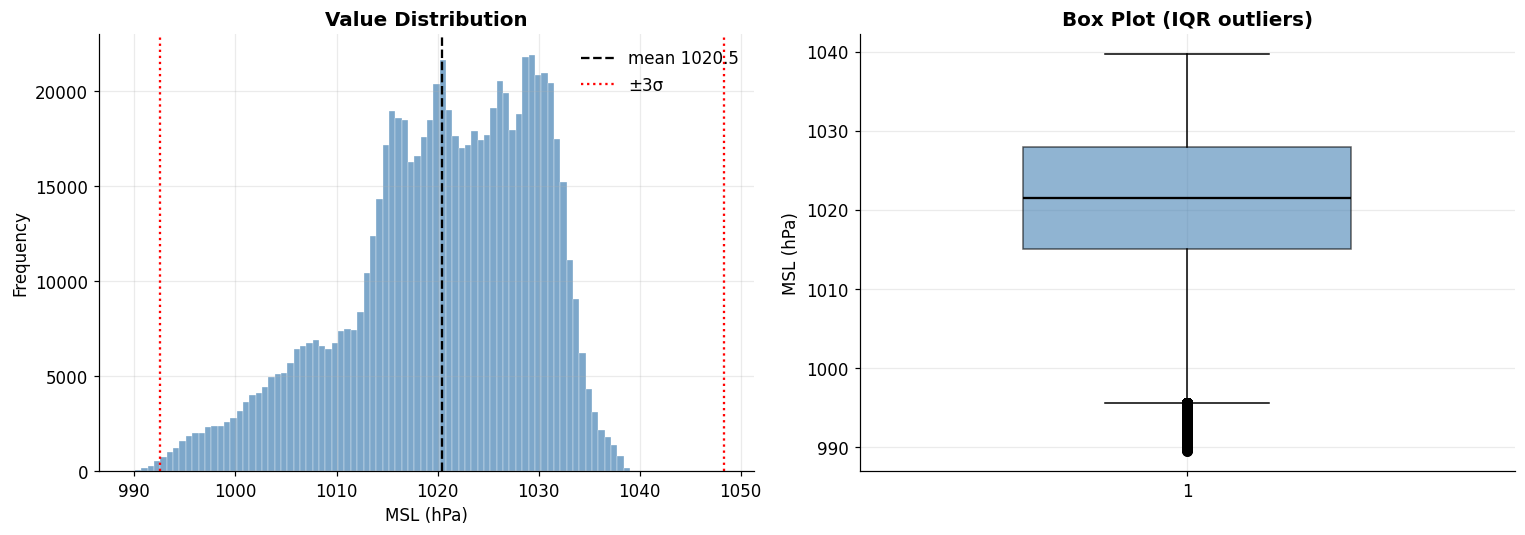

In [7]:
print('='*55)
print('  5. OUTLIER DETECTION')
print('='*55)

flat = samples.flatten()

# (a) Physical plausibility
phys_out = (flat < PHYS_MIN) | (flat > PHYS_MAX)
print(f'  Physically implausible (outside [{PHYS_MIN},{PHYS_MAX}] hPa): {phys_out.sum()}')

# (b) Z-score
mu, sd = flat.mean(), flat.std()
z = np.abs((flat - mu) / sd)
print(f'  Z-score > 3 : {(z>3).sum()}  ({100*(z>3).sum()/len(flat):.3f}%)')
print(f'  Z-score > 5 : {(z>5).sum()}  ({100*(z>5).sum()/len(flat):.3f}%)')

# (c) IQR
q1, q3 = np.percentile(flat, [25, 75])
iqr = q3 - q1
iqr_out = (flat < q1 - 1.5*iqr) | (flat > q3 + 1.5*iqr)
print(f'  IQR outliers: {iqr_out.sum()}  ({100*iqr_out.sum()/len(flat):.3f}%)')

# Clip ONLY physically implausible values (statistical extremes are kept)
n_clipped = phys_out.sum()
if n_clipped > 0:
    samples = np.clip(samples, PHYS_MIN, PHYS_MAX)
    print(f'\n  Clipped {n_clipped} physically implausible values to bounds')
else:
    print('\n  No physically implausible values — nothing clipped')
print('  Statistical extremes RETAINED (genuine weather events)')

qc_report['phys_outliers']  = int(phys_out.sum())
qc_report['zscore3_outliers'] = int((z>3).sum())
qc_report['iqr_outliers']   = int(iqr_out.sum())

# Visualise
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.hist(flat, bins=80, color='steelblue', alpha=0.7, edgecolor='white', linewidth=0.3)
ax1.axvline(mu, color='black', linestyle='--', label=f'mean {mu:.1f}')
ax1.axvline(mu+3*sd, color='red', linestyle=':', label='±3σ')
ax1.axvline(mu-3*sd, color='red', linestyle=':')
ax1.set(xlabel=f'{VARIABLE} ({UNIT})', ylabel='Frequency', title='Value Distribution')
ax1.legend()
ax2.boxplot(flat, vert=True, widths=0.5, patch_artist=True,
            boxprops=dict(facecolor='steelblue', alpha=0.6),
            medianprops=dict(color='black', linewidth=1.5))
ax2.set(ylabel=f'{VARIABLE} ({UNIT})', title='Box Plot (IQR outliers)')
plt.tight_layout(); plt.savefig('qc_outliers.png', bbox_inches='tight'); plt.show()

## 6. Dataset Balance & Coverage Assessment

For a gridded regression target, "imbalance" means uneven spatial or temporal coverage and skew in the value distribution. We check that every grid cell is equally represented, that the temporal axis is complete, and quantify the distribution skew/kurtosis — a heavily skewed target often benefits from a transform before training.

  6. BALANCE & COVERAGE
  Observations per grid point: 744 (uniform by construction)
  Spatial coverage: 1023 / 1023 expected points

  Distribution skewness: -0.633  (skewed — consider transform)
  Distribution kurtosis: -0.113  (near-normal tails)

  Per-cell temporal std: min=8.10  max=9.89  ratio=1.2x
  (high ratio = spatially heterogeneous variability, normal for pressure)


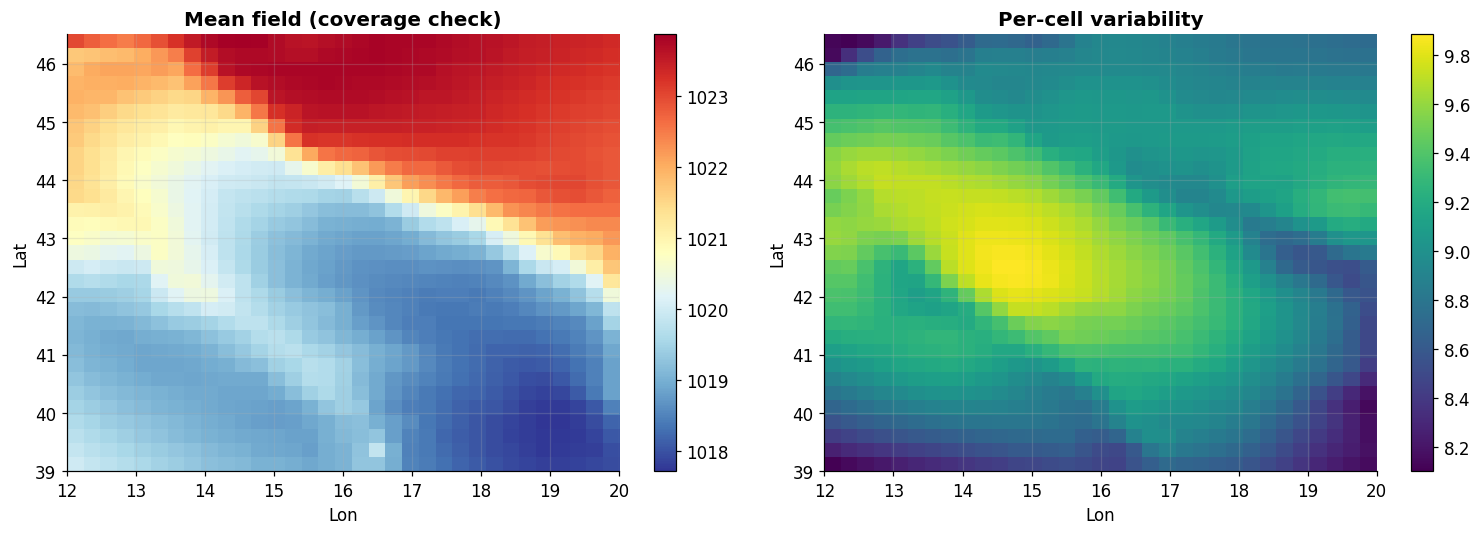

In [8]:
from scipy import stats as sps

print('='*55)
print('  6. BALANCE & COVERAGE')
print('='*55)

# Spatial coverage: every grid point should have identical n_hours
obs_per_point = samples.shape[1]
print(f'  Observations per grid point: {obs_per_point} (uniform by construction)')
print(f'  Spatial coverage: {samples.shape[0]} / {EXPECTED_LAT*EXPECTED_LON} expected points')

# Distribution shape
skew = sps.skew(flat)
kurt = sps.kurtosis(flat)
print(f'\n  Distribution skewness: {skew:+.3f}  ', end='')
print('(near-symmetric)' if abs(skew) < 0.5 else '(skewed — consider transform)')
print(f'  Distribution kurtosis: {kurt:+.3f}  ', end='')
print('(near-normal tails)' if abs(kurt) < 1 else '(heavy/light tails)')

# Per-cell mean variability (are some regions far more variable?)
cell_std = samples.std(axis=1)
print(f'\n  Per-cell temporal std: min={cell_std.min():.2f}  '
      f'max={cell_std.max():.2f}  ratio={cell_std.max()/cell_std.min():.1f}x')
print('  (high ratio = spatially heterogeneous variability, normal for pressure)')

qc_report['skewness'] = float(skew)
qc_report['kurtosis'] = float(kurt)

# Visualise spatial coverage + variability
def to_grid(values, lon, lat):
    lons = np.sort(np.unique(lon)); lats = np.sort(np.unique(lat))[::-1]
    grid = np.full((len(lats), len(lons)), np.nan)
    li = {v:i for i,v in enumerate(lons)}; la_ = {v:i for i,v in enumerate(lats)}
    for v, lo, l in zip(values, lon, lat): grid[la_[l], li[lo]] = v
    return grid

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
g_mean = to_grid(samples.mean(axis=1), lon, lat)
g_std  = to_grid(cell_std, lon, lat)
im1 = ax1.imshow(g_mean, cmap='RdYlBu_r', extent=[LON_MIN,LON_MAX,LAT_MIN,LAT_MAX], aspect='auto')
ax1.set(title='Mean field (coverage check)', xlabel='Lon', ylabel='Lat'); plt.colorbar(im1, ax=ax1)
im2 = ax2.imshow(g_std, cmap='viridis', extent=[LON_MIN,LON_MAX,LAT_MIN,LAT_MAX], aspect='auto')
ax2.set(title='Per-cell variability', xlabel='Lon', ylabel='Lat'); plt.colorbar(im2, ax=ax2)
plt.tight_layout(); plt.savefig('qc_coverage.png', bbox_inches='tight'); plt.show()

## 7. Normalisation

Z-score standardisation `(x − μ) / σ` using statistics computed on the **clean** data. These statistics are saved to JSON and **must be reused unchanged** at inference time — recomputing them on new data would shift the input distribution the model was trained on.

Z-score is preferred over min-max for this task: pressure has no hard physical bounds in the data, and z-score keeps genuine extremes proportionally represented rather than compressing them toward 0/1.

  7. NORMALISATION (z-score)
  Mean (μ): 1020.4692 hPa
  Std  (σ): 9.2973 hPa

  After normalisation:
    mean: 0.000000  (target 0)
    std : 1.000000  (target 1)
    range: [-3.34, 2.07]

  Saved -> norm_stats_msl.json


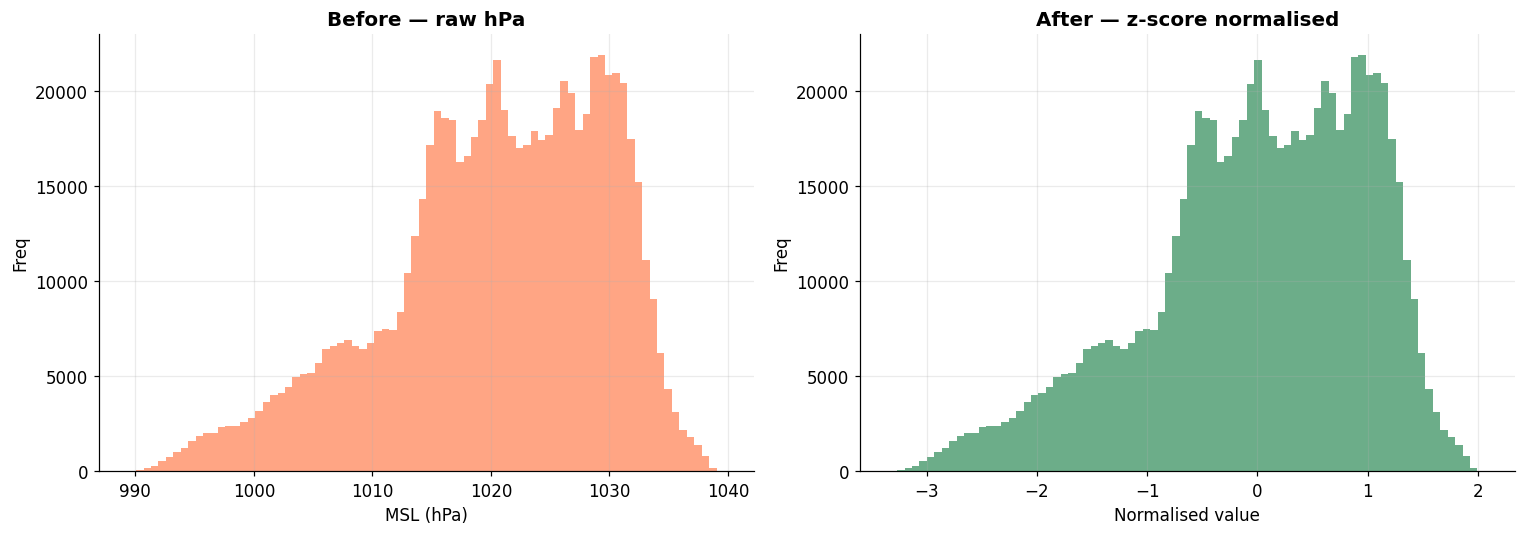

In [9]:
print('='*55)
print('  7. NORMALISATION (z-score)')
print('='*55)

norm_mean = float(samples.mean())
norm_std  = float(samples.std())

samples_norm = (samples - norm_mean) / norm_std
value_norm   = (value - norm_mean) / norm_std   # reference normalised with SAME stats

print(f'  Mean (μ): {norm_mean:.4f} {UNIT}')
print(f'  Std  (σ): {norm_std:.4f} {UNIT}')
print(f'\n  After normalisation:')
print(f'    mean: {samples_norm.mean():.6f}  (target 0)')
print(f'    std : {samples_norm.std():.6f}  (target 1)')
print(f'    range: [{samples_norm.min():.2f}, {samples_norm.max():.2f}]')

# Save normalisation stats — CRITICAL for inference consistency
norm_stats = {'variable': VARIABLE, 'unit': UNIT,
              'mean': norm_mean, 'std': norm_std, 'method': 'zscore'}
with open('norm_stats_msl.json', 'w') as f:
    json.dump(norm_stats, f, indent=2)
print(f'\n  Saved -> norm_stats_msl.json')

# Before/after visual
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.hist(samples.flatten(), bins=80, color='coral', alpha=0.7)
ax1.set(title=f'Before — raw {UNIT}', xlabel=f'{VARIABLE} ({UNIT})', ylabel='Freq')
ax2.hist(samples_norm.flatten(), bins=80, color='seagreen', alpha=0.7)
ax2.set(title='After — z-score normalised', xlabel='Normalised value', ylabel='Freq')
plt.tight_layout(); plt.savefig('qc_normalisation.png', bbox_inches='tight'); plt.show()

## 8. Export Clean Dataset + QC Report

Save the cleaned, normalised arrays as a `.npz` ready for the model, plus the full QC report as JSON for documentation and reproducibility.

In [10]:
OUT_NPZ = CSV_PATH.replace('.csv', '_clean.npz')
np.savez_compressed(
    OUT_NPZ,
    samples_norm=samples_norm.astype(np.float32),
    value_norm=value_norm.astype(np.float32),
    samples_raw=samples.astype(np.float32),
    lon=lon, lat=lat,
    norm_mean=norm_mean, norm_std=norm_std,
)

qc_report['final_shape']  = list(samples.shape)
qc_report['norm_mean']    = norm_mean
qc_report['norm_std']     = norm_std
with open('qc_report_msl.json', 'w') as f:
    json.dump(qc_report, f, indent=2)

print('='*55)
print('  EXPORT COMPLETE')
print('='*55)
print(f'  Clean data  -> {OUT_NPZ}')
print(f'  QC report   -> qc_report_msl.json')
print(f'  Norm stats  -> norm_stats_msl.json')
print(f'\n  Final clean tensor: {samples_norm.shape}  (points × hours)')
print(f'  Ready for model input.')
print('\n  ── QC SUMMARY ──')
for k, v in qc_report.items():
    print(f'    {k:22s}: {v}')

  EXPORT COMPLETE
  Clean data  -> final_2024_12_msl_clean.npz
  QC report   -> qc_report_msl.json
  Norm stats  -> norm_stats_msl.json

  Final clean tensor: (1023, 744)  (points × hours)
  Ready for model input.

  ── QC SUMMARY ──
    n_points              : 1023
    n_samples             : 744
    grid_ok               : True
    coords_in_domain      : True
    n_nan_samples         : 0
    pct_nan               : 0.0
    empty_columns         : 0
    bad_coord_points      : 0
    duplicate_coords      : 0
    phys_outliers         : 0
    zscore3_outliers      : 967
    iqr_outliers          : 6731
    skewness              : -0.6334821676502878
    kurtosis              : -0.11327503002884853
    final_shape           : [1023, 744]
    norm_mean             : 1020.4692406291712
    norm_std              : 9.297267589487499
